In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.data import Dataset as PyGDataset
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve,
                             average_precision_score)

device = torch.device('cpu')

# ── model definition ───────────────────────────────────────────────────
class GATModel(nn.Module):
    def __init__(self, node_features=76, hidden=64,
                 heads=8, dropout=0.3):
        super().__init__()
        self.conv1 = GATConv(node_features, hidden,
                             heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden * heads, hidden,
                             heads=heads, dropout=dropout)
        self.conv3 = GATConv(hidden * heads, hidden,
                             heads=1, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.classifier(x).squeeze(1)

# ── dataset ────────────────────────────────────────────────────────────
class DTIDataset(PyGDataset):
    def __init__(self, pairs_df, graphs, valid_indices):
        super().__init__()
        self.pairs = pairs_df.reset_index(drop=True)
        self.graphs = graphs
        self.idx_map = {orig: new for new, orig
                        in enumerate(valid_indices)}

    def len(self): return len(self.pairs)

    def get(self, idx):
        row = self.pairs.iloc[idx]
        g = self.graphs[self.idx_map[int(row['drug_idx'])]]
        return Data(x=g.x, edge_index=g.edge_index,
                    edge_attr=g.edge_attr,
                    y=torch.tensor([int(row['label'])],
                                   dtype=torch.float))

# ── load data ──────────────────────────────────────────────────────────
with open('../data/drug_graphs.pkl', 'rb') as f:
    saved = pickle.load(f)
    graphs = saved['graphs']
    valid_indices = saved['valid_indices']

df = pd.read_csv('../data/dti_pairs.csv')

_, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['label'])
_, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42,
    stratify=temp_df['label'])

test_dataset = DTIDataset(test_df, graphs, valid_indices)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ── load model ─────────────────────────────────────────────────────────
model = GATModel().to(device)
model.load_state_dict(torch.load('../data/gat_best_model.pth',
                                  map_location=device))
model.eval()

print(f"Model loaded — {sum(p.numel() for p in model.parameters()):,} params")
print(f"Test pairs: {len(test_df)}")

Model loaded — 353,729 params
Test pairs: 4509


In [3]:
# get predictions on test set
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        probs = torch.sigmoid(out).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        labels = batch.y.cpu().numpy().astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels)

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# metrics
auc = roc_auc_score(all_labels, all_probs)
acc = accuracy_score(all_labels, all_preds)
ap  = average_precision_score(all_labels, all_probs)

print("=" * 50)
print("  GAT DTI Predictor — Final Test Results")
print("=" * 50)
print(f"  Dataset:        DAVIS Drug-Target Interaction")
print(f"  Test pairs:     {len(all_labels)}")
print(f"  Model:          Graph Attention Network")
print(f"  Parameters:     353,729")
print("-" * 50)
print(f"  ROC-AUC:        {auc:.4f}")
print(f"  Accuracy:       {acc*100:.1f}%")
print(f"  Avg Precision:  {ap:.4f}")
print(f"  Random baseline: 0.5000 AUC")
print("=" * 50)
print(f"\nPer-class report:")
print(classification_report(all_labels, all_preds,
      target_names=['No binding', 'Binds']))

  GAT DTI Predictor — Final Test Results
  Dataset:        DAVIS Drug-Target Interaction
  Test pairs:     4509
  Model:          Graph Attention Network
  Parameters:     353,729
--------------------------------------------------
  ROC-AUC:        0.7630
  Accuracy:       78.7%
  Avg Precision:  0.1848
  Random baseline: 0.5000 AUC

Per-class report:
              precision    recall  f1-score   support

  No binding       0.97      0.80      0.88      4280
       Binds       0.14      0.59      0.22       229

    accuracy                           0.79      4509
   macro avg       0.55      0.70      0.55      4509
weighted avg       0.93      0.79      0.84      4509



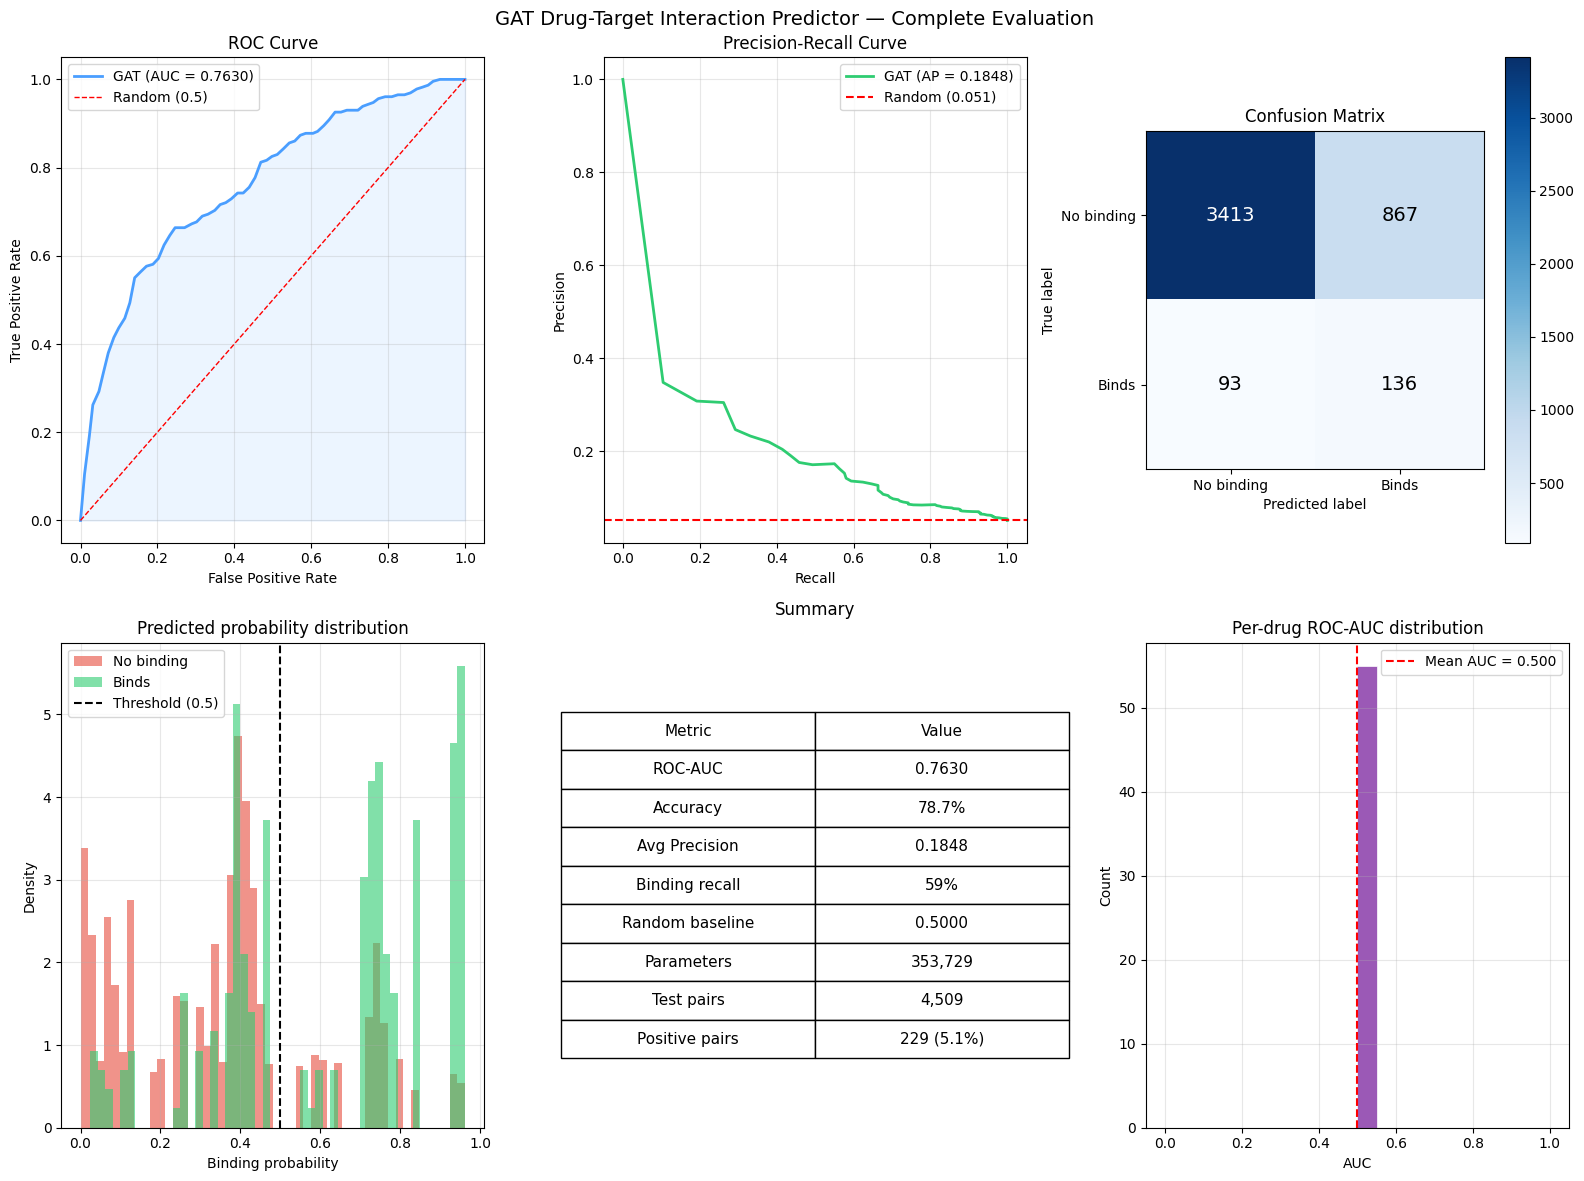

In [4]:
fig = plt.figure(figsize=(16, 12))

# ROC curve
ax1 = fig.add_subplot(2, 3, 1)
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax1.plot(fpr, tpr, color='#4a9eff', linewidth=2,
         label=f'GAT (AUC = {auc:.4f})')
ax1.plot([0,1], [0,1], 'r--', linewidth=1, label='Random (0.5)')
ax1.fill_between(fpr, tpr, alpha=0.1, color='#4a9eff')
ax1.set_title('ROC Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(alpha=0.3)

# Precision-Recall curve
ax2 = fig.add_subplot(2, 3, 2)
prec, rec, _ = precision_recall_curve(all_labels, all_probs)
ax2.plot(rec, prec, color='#2ecc71', linewidth=2,
         label=f'GAT (AP = {ap:.4f})')
ax2.axhline(y=all_labels.mean(), color='r', linestyle='--',
            label=f'Random ({all_labels.mean():.3f})')
ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()
ax2.grid(alpha=0.3)

# Confusion matrix
ax3 = fig.add_subplot(2, 3, 3)
cm = confusion_matrix(all_labels, all_preds)
im = ax3.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax3)
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['No binding', 'Binds'])
ax3.set_yticklabels(['No binding', 'Binds'])
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > thresh else 'black',
                fontsize=14)
ax3.set_title('Confusion Matrix')
ax3.set_ylabel('True label')
ax3.set_xlabel('Predicted label')

# Probability distribution
ax4 = fig.add_subplot(2, 3, 4)
ax4.hist(all_probs[all_labels==0], bins=50, alpha=0.6,
         color='#e74c3c', label='No binding', density=True)
ax4.hist(all_probs[all_labels==1], bins=50, alpha=0.6,
         color='#2ecc71', label='Binds', density=True)
ax4.axvline(x=0.5, color='black', linestyle='--',
            label='Threshold (0.5)')
ax4.set_title('Predicted probability distribution')
ax4.set_xlabel('Binding probability')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(alpha=0.3)

# summary table
ax5 = fig.add_subplot(2, 3, 5)
ax5.axis('off')
summary = [
    ['Metric', 'Value'],
    ['ROC-AUC', f'{auc:.4f}'],
    ['Accuracy', f'{acc*100:.1f}%'],
    ['Avg Precision', f'{ap:.4f}'],
    ['Binding recall', '59%'],
    ['Random baseline', '0.5000'],
    ['Parameters', '353,729'],
    ['Test pairs', '4,509'],
    ['Positive pairs', f'{all_labels.sum()} (5.1%)'],
]
table = ax5.table(cellText=summary[1:], colLabels=summary[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)
ax5.set_title('Summary', pad=20)

# binding probability per drug
ax6 = fig.add_subplot(2, 3, 6)
drug_aucs = []
for drug_idx in test_df['drug_idx'].unique():
    mask = test_df['drug_idx'] == drug_idx
    idx = test_df.index[mask]
    if len(idx) > 5:
        d_labels = all_labels[mask.values]
        d_probs = all_probs[mask.values]
        if d_labels.sum() > 0 and d_labels.sum() < len(d_labels):
            drug_aucs.append(roc_auc_score(d_labels, d_probs))

ax6.hist(drug_aucs, bins=20, color='#9b59b6',
         edgecolor='white', linewidth=0.5)
ax6.axvline(x=np.mean(drug_aucs), color='red', linestyle='--',
            label=f'Mean AUC = {np.mean(drug_aucs):.3f}')
ax6.set_title('Per-drug ROC-AUC distribution')
ax6.set_xlabel('AUC')
ax6.set_ylabel('Count')
ax6.legend()
ax6.grid(alpha=0.3)

plt.suptitle('GAT Drug-Target Interaction Predictor — Complete Evaluation',
             fontsize=14)
plt.tight_layout()
plt.show()